In [2]:
netlist = """\
3-bit Ripple Counter
Vclk clk_a 0 PULSE(0 5 0 1n 1n $HALF_PERIOD $PERIOD)

Aclk [clk_a] [clk_d] ADC1
.model ADC1 adc_bridge(in_low=0.8 in_high=2.0)

.model DFF1 d_dff(ic=0 clk_delay=10n rise_delay=10n fall_delay=10n)

A1 q0b_d clk_d null null q0_d q0b_d DFF1
A2 q1b_d q0_d  null null q1_d q1b_d DFF1
A3 q2b_d q1_d  null null q2_d q2b_d DFF1

Aq0 [q0_d] [q0] DAC1
Aq1 [q1_d] [q1] DAC1
Aq2 [q2_d] [q2] DAC1
.model DAC1 dac_bridge(out_low=0 out_high=5 out_undef=2.5 t_rise=1n t_fall=1n)

.SAVE $SAVE_VARS

.TRAN $TSTEP $TEND
.END
"""

with open('ripple_counter_orig.cir', 'w') as f:
    f.write(netlist)

print("ripple_counter_orig.cir written")

ripple_counter_orig.cir written


In [3]:
import ngspice_calc as calc
import numpy as np
import matplotlib.pyplot as plt

f_clk = 1e6 #1MHz clock
period = 1/f_clk
half_period = period/2
n_cycles = 16
tend = n_cycles * period
tstep = period / 200

print(f'Clock frequency: {f_clk/1e6:.1f} MHz')
print(f'Clock period: {period*1e9:.1f} ns')
print(f'Simulating {n_cycles} cycles')
print(f'Tend: {tend*1e6:.1f} us')

Clock frequency: 1.0 MHz
Clock period: 1000.0 ns
Simulating 16 cycles
Tend: 16.0 us


In [4]:
l = [
    ('$HALF_PERIOD', f'{half_period:.6e}'),
    ('$PERIOD', f'{period:.6e}'),
    ('$TSTEP', f'{tstep:.6e}'),
    ('$TEND', f'{tend:.6e}'),
    ('$SAVE_VARS', f'v(clk_a) v(q0) v(q1) v(q2)')
]

calc.replace_strings_1('ripple_counter_orig.cir', 'ripple_counter.cir', l)

In [5]:
calc.run_ngspice('ripple_counter.cir')


Note: No compatibility mode selected!


Circuit: 3-bit ripple counter

binary raw file "ripple_counter.raw"
Reducing trtol to 1 for xspice 'A' devices
Doing analysis at TEMP = 27.000000 and TNOM = 27.000000

Using SPARSE 1.3 as Direct Linear Solver
No. of Data Columns : 5  

Initial Transient Solution
--------------------------

Node                                   Voltage
----                                   -------
clk_a                                        0
q0                                           0
q1                                           0
q2                                           0
vclk#branch                                  0
aq2#branch_1_0                               0
aq1#branch_1_0                               0
aq0#branch_1_0                               0


No. of Data Rows : 3593

Total analysis time (seconds) = 0.0177222

Total elapsed time (seconds) = 0.021 

Total DRAM available = 15614.750 MB.
DRAM currently available = 1510.875 MB.
Maximum ngsp

'ripple_counter.raw'

In [6]:
s = calc.slv('ripple_counter.cir')

for i in range(s.num_plots()):
    print(f"plot {i}: {s.plotname(i)} | type: {s.analysis_type(i)} | vars: {s.variables(i)}")

plot 0: Transient Analysis | type: tran | vars: ['time', 'v(clk_a)', 'v(q0)', 'v(q1)', 'v(q2)']


In [7]:
t = s.get_array('time')
v_clk = s.get_array('v(clk_a)')
v_q0 = s.get_array('v(q0)')
v_q1 = s.get_array('v(q1)')
v_q2 = s.get_array('v(q2)')

print(f'Time range: {t[0]*1e6:.1f} us to {t[-1]*1e6:.1f} us')
print(f'Points: {len(t)}')

Time range: 0.0 us to 16.0 us
Points: 3593


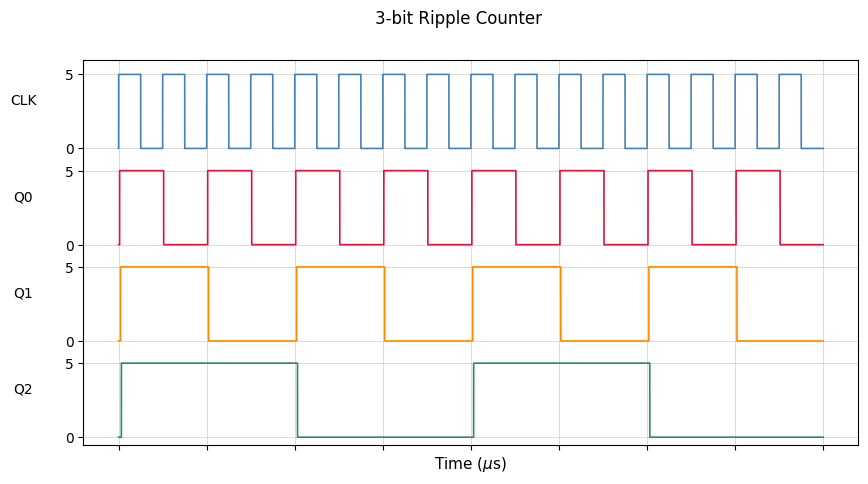

In [18]:
names = ['CLK', 'Q0', 'Q1', 'Q2']
arrays = [v_clk, v_q0, v_q1, v_q2]
colors = ['steelblue', 'crimson', 'darkorange', 'seagreen']

fig, axes = plt.subplots(4,1, figsize=(10, 5), sharex=True, gridspec_kw={'hspace': 0})


for ax,name,arr,color in zip(axes, names, arrays, colors):
    ax.plot(t*1e6, arr, color=color, linewidth=1.2, drawstyle='steps-post')
    ax.set_ylabel(name, fontsize=10, rotation=0, labelpad=30)
    ax.set_ylim(-0.5, 6)
    ax.set_yticks([0, 5])
    ax.grid(color='#CCCCCC', linestyle='solid', linewidth=0.5)
    ax.tick_params(labelbottom=False)

for ax in axes[:-1]:
    ax.spines['bottom'].set_visible(False)

for ax in axes[1:]:
    ax.spines['top'].set_visible(False)

axes[-1].set_xlabel(r'Time ($\mu$s)', fontsize=11)
plt.suptitle('3-bit Ripple Counter', fontsize=12)
plt.show()